# 🛡️ WellGuard — AI Model Development
**Proyek :** Nuraga (CC26-PRU428) — Integrated Safety Intelligence System  
**Fase    :** Phase 2 — Model Training (lanjutan dari EDA notebook `well.ipynb`)  
**Input   :** `wellguard.csv` — output dari EDA notebook  

---

## 📐 Arsitektur Pipeline

```
wellguard.csv  →  Feature Engineering  →  RobustScaler
                                              ↓
                              PLR Embedding  (12 fitur → 192 dim)
                                              ↓
                         Residual MLP [512→512→256→128] + SELU
                                              ↓
                    IMWA Training  (3 episode × 2 model paralel)
                    + Mixup Augmentation + EMA Weight Averaging
                    + Focal Loss + Label Smoothing
                                              ↓
                    Evaluasi: F1, ROC-AUC, SHAP, Confusion Matrix
```

## 🔬 Teknik Peningkatan Akurasi (Riset 2024–2025)

| Teknik | Referensi | Estimasi Gain |
|---|---|---|
| PLR Numerical Embedding | Gorishniy et al., NeurIPS 2022 | +3–8% |
| RobustScaler + SELU | RealMLP, NeurIPS 2024 | +2–5% |
| EMA Weight Averaging | Tabular MLP Benchmark 2025 | +1–3% |
| Mixup Augmentation (α=0.2) | Imbalanced-DL, 2024 | +1–4% |
| IMWA Multi-episode Training | ScienceDirect, 2024 | +2–4% |

## 📦 Cell 0 — Instalasi Dependensi

In [1]:
# Instalasi library tambahan yang diperlukan
!pip install -q shap==0.45.1

# Penjaga versi NumPy (harus < 2 agar kompatibel dengan PyTorch + SHAP)
import os
try:
    import numpy as _chk
    if int(_chk.__version__.split('.')[0]) >= 2:
        print(f'⚠️  NumPy {_chk.__version__} terdeteksi. Downgrade...')
        os.system("pip install -q 'numpy<2'")
        print('✅ Restart kernel secara manual lalu jalankan ulang.')
        os._exit(00)
    else:
        print(f'✅ NumPy {_chk.__version__} sudah sesuai.')
except Exception:
    pass

✅ NumPy 1.26.4 sudah sesuai.


## 📚 Cell 1 — Import Library

In [2]:
import warnings; warnings.filterwarnings('ignore')
import json, time, math, os
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
import joblib, shap

# --- NEW: Dictionary to keep figures in memory ---
SAVED_FIGS = {}

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Library siap  |  Device: {DEVICE}')

✅ Library siap  |  Device: cuda


## ⚙️ Cell 2 — Konfigurasi Global
Semua hyperparameter dan path terpusat di dict `CFG` agar mudah dimodifikasi.

In [5]:
# ── Mount Google Drive & tentukan path ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Path input: output CSV dari notebook EDA (well.ipynb)
CSV_PATH   = '/content/drive/My Drive/wellguard.csv'
OUTPUT_DIR = '/content/drive/MyDrive/WellGuard/model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Konfigurasi Model ────────────────────────────────────────────────────────
CFG = {
    # Fitur input (setelah feature engineering)
    # age, sex, sleep, stress, shift berasal dari wellguard.csv
    # sisanya adalah fitur turunan yang dibuat di Cell 3
    'feature_cols': [
        'age', 'sex', 'sleep', 'stress', 'shift',
        'stress_sleep_ratio',   # stress / sleep — indikator beban relatif
        'sleep_deficit',        # maks(0, 7-sleep) — hutang tidur
        'age_stress',           # age×stress / normalisasi — beban kumulatif
        'night_stress',         # shift malam × stress
        'cum_burden',           # sleep_deficit × stress
        'sleep_eff',            # sleep / (stress+1) — efisiensi tidur
        'age_group_ord',        # encoding ordinal dari age_group
    ],
    'target_col' : 'fatigue',
    'n_classes'  : 3,

    # ── PLR Embedding ─────────────────────────────────────────────────────────
    # emb_dim: dimensi K per fitur; backbone input = 12 × 16 = 192
    # sigma  : std inisialisasi frekuensi — tuning jika perlu (coba 0.1–2.0)
    'plr_emb_dim': 16,
    'plr_sigma'  : 1.0,

    # ── Arsitektur Backbone ────────────────────────────────────────────────────
    # Lebih besar dari v1 karena PLR menambah dimensi input (192 vs 12)
    'hidden_dims'   : [512, 512, 256, 128],
    'dropout_rates' : (0.3, 0.3, 0.2, 0.1),

    # ── Training ──────────────────────────────────────────────────────────────
    'n_epochs'    : 150,
    'lr'          : 3e-4,
    'weight_decay': 1e-4,
    'batch_size'  : 256,
    'grad_clip'   : 0.5,

    # ── Teknik Peningkatan ─────────────────────────────────────────────────────
    'mixup_alpha'   : 0.2,    # Beta(α,α); 0.0 = nonaktif
    'ema_decay'     : 0.999,  # θ_ema = decay·θ_ema + (1-decay)·θ
    'imwa_episodes' : 3,      # jumlah episode IMWA

    # ── Loss Function ──────────────────────────────────────────────────────────
    'focal_gamma'    : 2.0,
    'label_smoothing': 0.1,

    # ── Early Stopping ─────────────────────────────────────────────────────────
    'patience' : 20,
    'min_delta': 1e-4,

    # ── Path Output ────────────────────────────────────────────────────────────
    'output_dir'      : OUTPUT_DIR,
    'best_model_path' : f'{OUTPUT_DIR}/wellguard_model.pt',
    'scaler_path'     : f'{OUTPUT_DIR}/robust_scaler.pkl',
    'meta_path'       : f'{OUTPUT_DIR}/model_meta.json',
}

N_FEAT_RAW = len(CFG['feature_cols'])            # 12
N_FEAT_EMB = N_FEAT_RAW * CFG['plr_emb_dim']    # 192
N_CLASSES  = CFG['n_classes']                    # 3

print(f'✅ Konfigurasi dimuat.')
print(f'   Fitur input mentah : {N_FEAT_RAW}')
print(f'   Setelah PLR embed  : {N_FEAT_EMB}  ({N_FEAT_RAW} × {CFG["plr_emb_dim"]})')
print(f'   Kelas target       : {N_CLASSES}  (0=Rendah, 1=Sedang, 2=Tinggi)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Konfigurasi dimuat.
   Fitur input mentah : 12
   Setelah PLR embed  : 192  (12 × 16)
   Kelas target       : 3  (0=Rendah, 1=Sedang, 2=Tinggi)


## 🔧 Cell 3 — Load Data & Feature Engineering
Data dimuat dari `wellguard.csv` (output EDA notebook).  
Enam fitur turunan ditambahkan untuk memperkaya representasi.

In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rekayasa fitur dari kolom dasar wellguard.csv.

    Kolom dasar yang tersedia:
        age, sex, sleep, stress, shift, age_group

    Fitur turunan yang ditambahkan:
        stress_sleep_ratio : beban stres relatif terhadap kualitas tidur
        sleep_deficit      : kekurangan tidur dari target 7 jam
        age_stress         : interaksi usia × stres (dinormalisasi)
        night_stress       : dampak shift malam pada tingkat stres
        cum_burden         : beban kumulatif = deficit × stres
        sleep_eff          : efisiensi tidur relatif terhadap stres
        age_group_ord      : encoding ordinal dari kategorisasi usia

    Epsilon 1e-6 ditambahkan pada semua pembagian untuk menghindari ZeroDivisionError.
    """
    d = df.copy()

    # Pastikan kolom shift ada (di wellguard.csv bisa jadi sudah ada)
    if 'shift' not in d.columns:
        d['shift'] = 1   # default: shift siang

    d['stress_sleep_ratio'] = d['stress'] / (d['sleep'].clip(lower=0.5) + 1e-6)
    d['sleep_deficit']      = (7.0 - d['sleep']).clip(lower=0.0)
    d['age_stress']         = (d['age'] * d['stress']) / (60 * 10)
    d['night_stress']       = (d['shift'] == 2).astype(float) * d['stress']
    d['cum_burden']         = d['sleep_deficit'] * d['stress']
    d['sleep_eff']          = d['sleep'] / (d['stress'] + 1.0 + 1e-6)

    # Encoding ordinal age_group
    if 'age_group' in d.columns:
        age_map = {'Muda (<30)': 0, 'Dewasa (30-45)': 1, 'Senior (>45)': 2}
        d['age_group_ord'] = d['age_group'].map(age_map).fillna(1).astype(int)
    else:
        d['age_group_ord'] = pd.cut(
            d['age'], bins=[-np.inf, 30, 45, np.inf], labels=[0, 1, 2]
        ).astype(int)

    return d


# ── Load Data ────────────────────────────────────────────────────────────────
try:
    df_raw = pd.read_csv(CSV_PATH)
    print(f'✅ wellguard.csv dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
    print(f'   Kolom tersedia: {list(df_raw.columns)}')
except FileNotFoundError:
    raise SystemExit(
        '❌ wellguard.csv tidak ditemukan. '
        'Jalankan notebook EDA (well.ipynb) terlebih dahulu untuk menghasilkan file ini.'
    )

# ── Feature Engineering ───────────────────────────────────────────────────────
df = engineer_features(df_raw)

# ── Siapkan X dan y ──────────────────────────────────────────────────────────
# Validasi: pastikan semua kolom fitur ada
missing_cols = [c for c in CFG['feature_cols'] if c not in df.columns]
if missing_cols:
    raise ValueError(f'❌ Kolom berikut tidak ditemukan setelah feature engineering: {missing_cols}')

# --- NEW: Handle NaNs in df for feature columns before converting to X_all ---
for col in CFG['feature_cols']:
    if df[col].isnull().any():
        median_val = df[col].median()
        print(f'⚠️  Mengatasi NaN di kolom "{col}" dengan imputasi median ({median_val}).')
        df[col].fillna(median_val, inplace=True)

X_all = df[CFG['feature_cols']].values.astype(np.float32)
y_all = df[CFG['target_col']].values.astype(np.int64)

# ── Ringkasan Data ────────────────────────────────────────────────────────────
unique, counts = np.unique(y_all, return_counts=True)
label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
print(f'\n✅ Feature engineering selesai.')
print(f'   Total sampel  : {X_all.shape[0]:,}')
print(f'   Jumlah fitur  : {X_all.shape[1]}')
print(f'   Distribusi kelas:')
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_all) * 100
    bar = '█' * int(pct / 2)
    print(f'     {label_map[cls]:7s} (label={cls}): {cnt:5,} sampel ({pct:5.1f}%)  {bar}')

# Cek NaN final
nan_count = np.isnan(X_all).sum()
print(f'   NaN di X      : {nan_count}  ({"✅ Bersih" if nan_count == 0 else "⚠️ Perlu ditangani"})')

✅ wellguard.csv dimuat: 102,000 baris × 10 kolom
   Kolom tersedia: ['id', 'age', 'sex', 'sleep', 'stress', 'shift', 'fatigue', 'fatigue_label', 'sex_label', 'age_group']
⚠️  Mengatasi NaN di kolom "sex" dengan imputasi median (0.0).

✅ Feature engineering selesai.
   Total sampel  : 102,000
   Jumlah fitur  : 12
   Distribusi kelas:
     Rendah  (label=0): 22,589 sampel ( 22.1%)  ███████████
     Sedang  (label=1): 69,520 sampel ( 68.2%)  ██████████████████████████████████
     Tinggi  (label=2): 9,891 sampel (  9.7%)  ████
   NaN di X      : 0  (✅ Bersih)


## 🔍 Cell 4 — Visualisasi Distribusi Fitur Engineering
Verifikasi visual bahwa fitur turunan memiliki distribusi yang masuk akal.

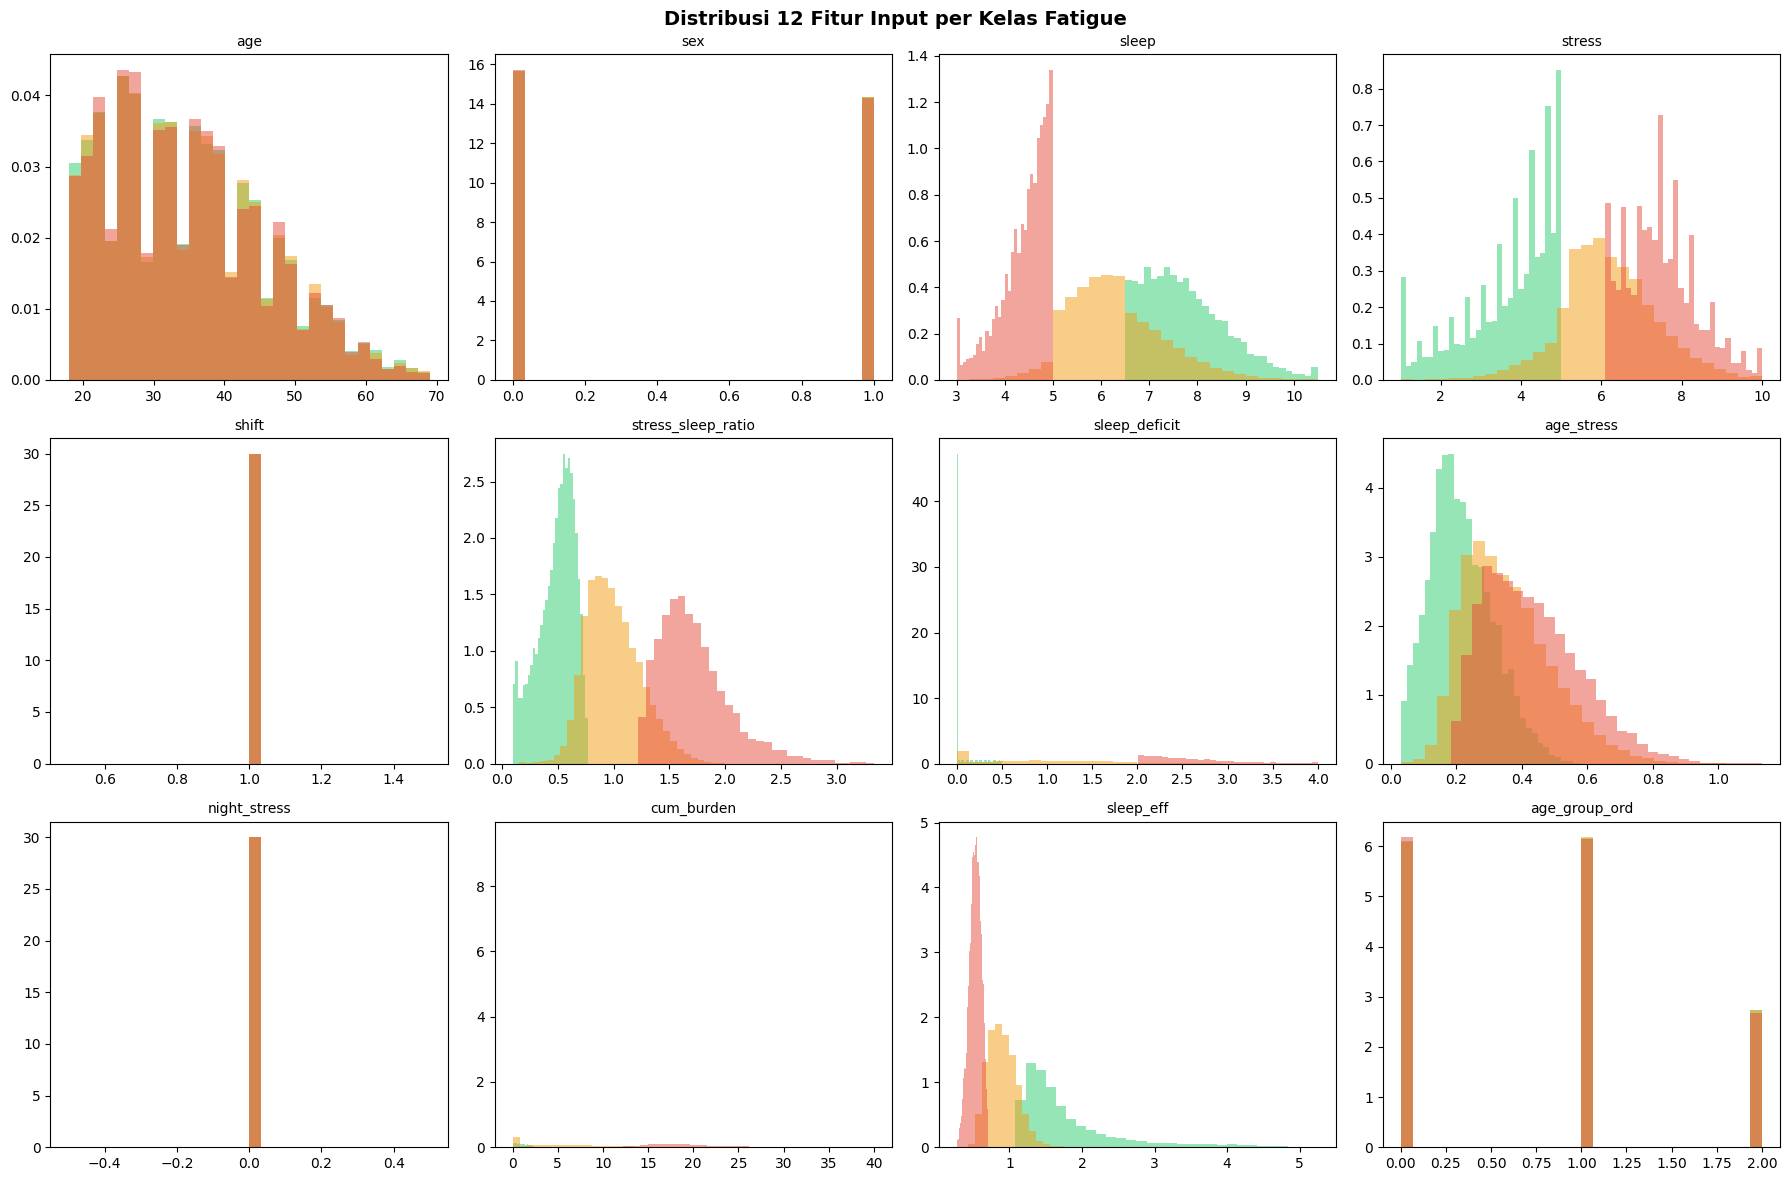

In [7]:
PALETTE = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
LABEL_MAP = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}

fig_dist, axes = plt.subplots(3, 4, figsize=(18, 12))
fig_dist.suptitle('Distribusi 12 Fitur Input per Kelas Fatigue', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(CFG['feature_cols']):
    ax = axes[i]
    for cls in [0, 1, 2]:
        mask = y_all == cls
        ax.hist(X_all[mask, i], bins=30, alpha=0.5,
                color=PALETTE[cls], label=LABEL_MAP[cls], density=True)
    ax.set_title(feat, fontsize=10)

plt.tight_layout()
SAVED_FIGS['dist'] = fig_dist # Simpan ke dictionary
plt.show()

## 🗄️ Cell 5 — Dataset & DataLoader
`WeightedRandomSampler` memastikan setiap batch memiliki representasi yang seimbang antar kelas.

In [8]:
class FatigueDataset(Dataset):
    """
    Dataset PyTorch untuk data fatigue karyawan.
    X disimpan sebagai float32, y sebagai int64 (untuk CrossEntropyLoss).
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


def build_weighted_sampler(y: np.ndarray) -> WeightedRandomSampler:
    """
    Membuat sampler agar frekuensi sampling berbanding terbalik dengan
    jumlah sampel per kelas → batch yang seimbang tanpa oversampling data.
    """
    class_counts  = np.bincount(y)
    class_weights = 1.0 / class_counts          # invers frekuensi
    sample_weights = class_weights[y]           # bobot tiap sampel
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(y),
        replacement=True,
    )


def build_loaders(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    batch_size: int = 256,
) -> tuple:
    """
    Membangun DataLoader train dan validasi.
    Train: WeightedRandomSampler + drop_last=True (BatchNorm butuh batch>1).
    Val  : Sequential, batch dua kali lebih besar untuk efisiensi.
    """
    sampler = build_weighted_sampler(y_tr)
    tr_loader = DataLoader(
        FatigueDataset(X_tr, y_tr),
        batch_size=batch_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=(DEVICE == 'cuda'),
        drop_last=True,
    )
    va_loader = DataLoader(
        FatigueDataset(X_val, y_val),
        batch_size=batch_size * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE == 'cuda'),
    )
    return tr_loader, va_loader


print('✅ FatigueDataset dan build_loaders siap.')

✅ FatigueDataset dan build_loaders siap.


## 🧮 Cell 6 — PLR Numerical Embedding
**Mengapa diperlukan:**  
Fitur numerik tabular biasanya masuk ke jaringan sebagai scalar tunggal — representasi yang sangat miskin.  
PLR mengubah setiap scalar menjadi vektor periodik berdimensi K, memberikan model kemampuan menangkap pola non-linear yang jauh lebih kaya.

**Referensi:** Gorishniy et al., *"On Embeddings for Numerical Features in Tabular Deep Learning"*, NeurIPS 2022

In [9]:
class PLREmbedding(nn.Module):
    """
    Periodic Linear ReLU (PLR) Embedding untuk fitur numerik tabular.

    ALUR KOMPUTASI:
    ──────────────
    Input  x : (B, F)      — B=batch size, F=n_features scalar

    Step 1 — Hitung argumen periodik:
        v[b,f,k] = 2π · c[f,k] · x[b,f]
        c = self.freqs (F,K) — frekuensi yang dipelajari, init N(0,σ)

    Step 2 — Embedding periodik (sin + cos):
        emb[b,f] = concat[sin(v[b,f,:]), cos(v[b,f,:])]  → (B, F, 2K)

    Step 3 — Proyeksi linear + ReLU:
        out = ReLU(W · flatten(emb) + b)  → (B, F*K)

    MENGAPA EFEKTIF:
    ────────────────
    - Fungsi periodik mampu merepresentasikan pola berulang
      (mis. pola tidur mingguan, siklus shift)
    - Setiap fitur di-embed SECARA TERPISAH sebelum digabung
      (kunci keberhasilan: tidak ada cross-feature mixing di tahap ini)
    - σ (sigma) adalah hyperparameter penting:
      kecil (0.1) = variasi lambat, besar (2.0) = variasi cepat

    Parameter:
        n_features : jumlah fitur F
        emb_dim    : K, dimensi embedding per fitur
        sigma      : std inisialisasi frekuensi
    """
    def __init__(self, n_features: int, emb_dim: int = 16, sigma: float = 1.0):
        super().__init__()
        self.n_features = n_features
        self.emb_dim    = emb_dim

        # Parameter frekuensi yang bisa dipelajari
        self.freqs = nn.Parameter(
            torch.randn(n_features, emb_dim) * sigma
        )
        # Linear layer: F*2K → F*K
        self.linear = nn.Linear(n_features * emb_dim * 2, n_features * emb_dim)
        self.act    = nn.ReLU()

        nn.init.kaiming_uniform_(self.linear.weight, nonlinearity='relu')
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, F)  →  v: (B, F, K)
        v   = 2.0 * math.pi * x.unsqueeze(-1) * self.freqs
        # Konkatenasi sin dan cos → (B, F, 2K)
        emb = torch.cat([v.sin(), v.cos()], dim=-1)
        # Ratakan dan proyeksikan → (B, F*K)
        return self.act(self.linear(emb.flatten(1)))


# ── Verifikasi dimensi ────────────────────────────────────────────────────────
_test_plr = PLREmbedding(N_FEAT_RAW, CFG['plr_emb_dim'], CFG['plr_sigma'])
_x_dummy  = torch.randn(4, N_FEAT_RAW)
_out      = _test_plr(_x_dummy)
print(f'✅ PLREmbedding siap.')
print(f'   Input : {_x_dummy.shape}  →  Output: {_out.shape}')
print(f'   Param frekuensi (freqs): {_test_plr.freqs.shape}')

✅ PLREmbedding siap.
   Input : torch.Size([4, 12])  →  Output: torch.Size([4, 192])
   Param frekuensi (freqs): torch.Size([12, 16])


## 🏗️ Cell 7 — Arsitektur Model: WellGuardMLP

**Alur data lengkap:**
```
Input (B, 12)
   ↓  PLREmbedding
(B, 192)   ← setiap scalar diubah ke 16-dim periodik
   ↓  BatchNorm1d
   ↓  ResidualBlock [192→512]  + SELU + Dropout(0.3)
   ↓  ResidualBlock [512→512]  + SELU + Dropout(0.3)
   ↓  ResidualBlock [512→256]  + SELU + Dropout(0.2)
   ↓  ResidualBlock [256→128]  + SELU + Dropout(0.1)
   ↓  Linear [128→3]
Logits (B, 3)
```

**Mengapa SELU bukan GELU/ReLU:**  
RealMLP (NeurIPS 2024) menemukan SELU secara konsisten lebih baik untuk tabular classification karena sifat *self-normalizing*-nya menstabilkan aktivasi tanpa BatchNorm tambahan.

In [10]:
class ResidualBlock(nn.Module):
    """
    Residual block dengan BatchNorm dan SELU activation.

    Struktur:
        x → Linear → BN → SELU → Dropout → Linear → BN → (+proj(x)) → SELU

    Skip connection (proj) menggunakan Linear jika dimensi berubah,
    Identity jika dimensi tetap.
    """
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.3):
        super().__init__()
        self.fc1  = nn.Linear(in_dim,  out_dim)
        self.bn1  = nn.BatchNorm1d(out_dim)
        self.act  = nn.SELU()                          # Self-normalizing
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(out_dim, out_dim)
        self.bn2  = nn.BatchNorm1d(out_dim)
        # Proyeksi skip connection jika dimensi berbeda
        self.proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.proj(x)
        out = self.act(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        return self.act(out + identity)   # residual connection


class WellGuardMLP(nn.Module):
    """
    WellGuard Fatigue Prediction Model.

    Komponen utama:
        1. PLREmbedding   — proyeksi fitur numerik ke ruang periodik
        2. BatchNorm1d    — normalisasi input ke backbone
        3. ResidualBlocks — 4 blok residual dengan SELU
        4. Linear head    — klasifikasi ke 3 kelas fatigue

    Inisialisasi bobot:
        Kaiming uniform untuk semua Linear layer (sesuai SELU/ReLU).

    Method tambahan:
        predict_proba(x) — return softmax probability (inference mode)
    """
    def __init__(
        self,
        n_features    : int,
        n_classes     : int,
        emb_dim       : int   = 16,
        sigma         : float = 1.0,
        hidden_dims   : tuple = (512, 512, 256, 128),
        dropout_rates : tuple = (0.3, 0.3, 0.2, 0.1),
    ):
        super().__init__()
        backbone_in = n_features * emb_dim

        self.embedder = PLREmbedding(n_features, emb_dim, sigma)
        self.input_bn = nn.BatchNorm1d(backbone_in)

        dims = [backbone_in] + list(hidden_dims)
        self.blocks = nn.ModuleList([
            ResidualBlock(dims[i], dims[i+1], dropout_rates[i])
            for i in range(len(hidden_dims))
        ])
        self.head = nn.Linear(hidden_dims[-1], n_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.embedder(x)      # (B,F) → (B, F*K)
        x = self.input_bn(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)       # (B, n_classes)

    @torch.no_grad()
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        return F.softmax(self.forward(x), dim=1)


# ── Preview model ─────────────────────────────────────────────────────────────
def make_model() -> WellGuardMLP:
    """Factory function — dipakai berulang di IMWA training."""
    return WellGuardMLP(
        n_features=N_FEAT_RAW,
        n_classes=N_CLASSES,
        emb_dim=CFG['plr_emb_dim'],
        sigma=CFG['plr_sigma'],
        hidden_dims=tuple(CFG['hidden_dims']),
        dropout_rates=CFG['dropout_rates'],
    ).to(DEVICE)

_preview = make_model()
n_params = sum(p.numel() for p in _preview.parameters() if p.requires_grad)
print(f'✅ WellGuardMLP siap.')
print(f'   Total parameter yang bisa dilatih: {n_params:,}')
print(f'   Input  : (B, {N_FEAT_RAW})  →  PLR  →  (B, {N_FEAT_EMB})')
print(f'   Output : (B, {N_CLASSES})')

✅ WellGuardMLP siap.
   Total parameter yang bisa dilatih: 1,476,867
   Input  : (B, 12)  →  PLR  →  (B, 192)
   Output : (B, 3)


## 📉 Cell 8 — Loss Function: Focal Loss + Label Smoothing
Dua teknik digabungkan untuk menangani class imbalance:
- **Focal Loss** — mengurangi bobot loss pada sampel mudah, fokus pada sampel sulit (minoritas)
- **Label Smoothing** — mengurangi overconfidence model, meningkatkan kalibrasi probabilitas

In [11]:
class FocalLossWithSmoothing(nn.Module):
    """
    Focal Loss dikombinasikan dengan Label Smoothing.

    FOCAL LOSS:
        FL(p_t) = (1 - p_t)^γ · CE(p_t)
        γ=2 → sampel dengan p_t=0.9 diboboti 100× lebih ringan
        dari sampel dengan p_t=0.1

    LABEL SMOOTHING:
        y_smooth = (1-ε)·y_one_hot + ε/n_classes
        ε=0.1 → distribusi target diperhalus

    ALPHA (class weights):
        Dihitung dari compute_class_weight('balanced')
        → kelas minoritas mendapat bobot lebih besar

    Parameter:
        gamma     : faktor fokus (2.0 = standar)
        alpha     : list bobot per kelas
        epsilon   : koefisien label smoothing
        n_classes : jumlah kelas
    """
    def __init__(
        self,
        gamma     : float = 2.0,
        alpha           = None,
        epsilon   : float = 0.1,
        n_classes : int   = 3,
        reduction : str   = 'mean',
    ):
        super().__init__()
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.n_classes = n_classes
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_prob = F.log_softmax(logits, dim=1)
        prob     = log_prob.exp().clamp(min=1e-7, max=1.0 - 1e-7)

        # Label smoothing
        with torch.no_grad():
            smooth = torch.full_like(log_prob, self.epsilon / self.n_classes)
            smooth.scatter_(1, targets.unsqueeze(1),
                            1.0 - self.epsilon + self.epsilon / self.n_classes)

        ce  = -(smooth * log_prob).sum(dim=1)
        p_t = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        fw  = (1.0 - p_t) ** self.gamma

        if self.alpha is not None:
            fw = self.alpha.gather(0, targets) * fw

        loss = fw * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


print('✅ FocalLossWithSmoothing siap.')

✅ FocalLossWithSmoothing siap.


## 🔀 Cell 9 — Mixup Augmentation
**Mengapa Mixup efektif untuk imbalanced classification:**  
Secara implisit menciptakan margin yang tidak seragam antara kelas mayoritas dan minoritas, sehingga model lebih sulit overfit ke kelas dominan.

**Referensi:** *"From SMOTE to Mixup for Deep Imbalanced Classification"*, 2024

In [12]:
def mixup_tabular(
    X     : torch.Tensor,
    y     : torch.Tensor,
    alpha : float = 0.2,
) -> tuple:
    """
    Mixup augmentation untuk data tabular.

    Formulasi:
        λ     ~ Beta(α, α)
        λ     = max(λ, 1-λ)        ← label asli tetap dominan
        X_mix = λ·X_i + (1-λ)·X_j  (j = indeks batch yang dipermutasi)

    Loss saat training:
        L = λ·CE(pred, y_i) + (1-λ)·CE(pred, y_j)

    Parameter:
        alpha : 0.0 = nonaktif, 0.1–0.4 = rentang praktis untuk tabular

    Return:
        X_mix, y_asli, y_pasangan, lambda
    """
    if alpha <= 0.0:
        return X, y, y, 1.0

    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1.0 - lam)          # pastikan λ ≥ 0.5

    idx   = torch.randperm(X.size(0), device=X.device)
    X_mix = lam * X + (1.0 - lam) * X[idx]
    return X_mix, y, y[idx], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam) -> torch.Tensor:
    """Loss function yang kompatibel dengan Mixup."""
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


print('✅ Mixup augmentation siap. (α =', CFG['mixup_alpha'], ')')

✅ Mixup augmentation siap. (α = 0.2 )


## 📊 Cell 10 — EMA (Exponential Moving Average)
Setelah setiap `optimizer.step()`, EMA menyimpan rata-rata bergerak parameter:
```
θ_shadow = decay · θ_shadow + (1 - decay) · θ_model
```
Evaluasi menggunakan `θ_shadow` (lebih halus, lebih stabil) bukan `θ_model`.

**Referensi:** *"Benchmarking Optimizers for MLPs in Tabular Deep Learning"*, 2025

In [13]:
class EMAModel:
    """
    Exponential Moving Average untuk parameter model.

    Cara kerja:
        update()        — perbarui shadow setelah setiap optimizer.step()
        apply_shadow()  — ganti bobot model dengan shadow untuk evaluasi
        restore()       — kembalikan bobot asli setelah evaluasi

    Keunggulan:
        - Gratis: tidak ada forward/backward pass tambahan
        - Mengurangi noise dari update gradient batch kecil
        - Secara konsisten meningkatkan val accuracy ~1–3%
    """
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay  = decay
        self.shadow = {
            n: p.data.clone()
            for n, p in model.named_parameters() if p.requires_grad
        }
        self.backup: dict = {}

    def update(self, model: nn.Module):
        """Perbarui shadow setelah optimizer.step()."""
        with torch.no_grad():
            for n, p in model.named_parameters():
                if p.requires_grad:
                    self.shadow[n] = (
                        self.decay * self.shadow[n]
                        + (1.0 - self.decay) * p.data
                    )

    def apply_shadow(self, model: nn.Module):
        """Terapkan shadow weights untuk inferensi/evaluasi."""
        with torch.no_grad():
            for n, p in model.named_parameters():
                if p.requires_grad:
                    self.backup[n] = p.data.clone()
                    p.data.copy_(self.shadow[n])

    def restore(self, model: nn.Module):
        """Kembalikan bobot asli setelah evaluasi."""
        with torch.no_grad():
            for n, p in model.named_parameters():
                if p.requires_grad and n in self.backup:
                    p.data.copy_(self.backup[n])
        self.backup.clear()


print(f'✅ EMAModel siap. (decay = {CFG["ema_decay"]})')

✅ EMAModel siap. (decay = 0.999)


## ⏹️ Cell 11 — Early Stopping & Training Loop

In [14]:
class EarlyStopping:
    """
    Early stopping berbasis validasi loss.
    Model terbaik disimpan otomatis ke `save_path`.
    NaN pada val_loss diabaikan (tidak dihitung sebagai tidak ada peningkatan).
    """
    def __init__(self, patience: int = 20, min_delta: float = 1e-4, save_path: str = 'best.pt'):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best      = float('inf')
        self.counter   = 0

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if np.isnan(val_loss):
            return False
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(
    model       : nn.Module,
    loader      : DataLoader,
    criterion   : nn.Module,
    optimizer   : torch.optim.Optimizer,
    amp_scaler  : GradScaler,
    device      : str,
    ema         : EMAModel | None = None,
    mixup_alpha : float = 0.2,
) -> float:
    """
    Satu epoch training dengan:
      - Mixup augmentation
      - Mixed Precision (AMP) untuk GPU
      - Gradient Clipping (max_norm=0.5)
      - EMA update setelah setiap optimizer step
      - Proteksi NaN/Inf pada input dan loss
    """
    model.train()
    total_loss, n = 0.0, 0

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)

        # Lewati batch dengan nilai tidak valid
        if torch.isnan(X_b).any() or torch.isinf(X_b).any():
            continue

        X_mix, y_a, y_b2, lam = mixup_tabular(X_b, y_b, alpha=mixup_alpha)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device == 'cuda')):
            logits = model(X_mix)
            loss   = (mixup_criterion(criterion, logits, y_a, y_b2, lam)
                      if lam < 1.0 else criterion(logits, y_b))

        if torch.isnan(loss):
            continue

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG['grad_clip'])
        amp_scaler.step(optimizer)
        amp_scaler.update()

        if ema is not None:
            ema.update(model)

        total_loss += loss.item() * len(y_b)
        n          += len(y_b)

    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(
    model     : nn.Module,
    loader    : DataLoader,
    criterion : nn.Module,
    device    : str,
    ema       : EMAModel | None = None,
) -> tuple:
    """
    Evaluasi model. Jika EMA disediakan, gunakan shadow weights.
    Return: (val_loss, val_accuracy)
    """
    if ema is not None:
        ema.apply_shadow(model)

    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits    = model(X_b)
        loss      = criterion(logits, y_b)
        correct  += (logits.argmax(1) == y_b).sum().item()
        total_loss += loss.item() * len(y_b)
        n += len(y_b)

    if ema is not None:
        ema.restore(model)

    return total_loss / max(n, 1), correct / max(n, 1)


print('✅ EarlyStopping, train_one_epoch, evaluate siap.')

✅ EarlyStopping, train_one_epoch, evaluate siap.


## 🔄 Cell 12 — IMWA: Iterative Model Weight Averaging

**Algoritma IMWA:**
```
shared_state ← bobot awal (random)
for episode = 1..N:
    for p = 1..P (paralel):
        model_p ← load(shared_state)
        latih model_p selama n_epoch/N epoch
    shared_state ← rata-rata(model_1, ..., model_P)
    if val_loss(shared_state) terbaik → simpan
return model(shared_state_terbaik)
```

**Mengapa efektif untuk imbalanced data:**  
Averaging di tahap awal training (sebelum overfit ke kelas mayoritas) memberikan gain terbesar. Sinergi dengan EMA: EMA meratakan dalam satu run, IMWA meratakan antar run.

**Referensi:** *"IMWA: Iterative Model Weight Averaging benefits class-imbalanced learning"*, ScienceDirect 2024

In [15]:
def average_model_weights(models: list) -> dict:
    """
    Rata-rata aritmetika state_dict dari daftar model.
    Semua parameter di-cast ke float32 sebelum dirata-rata
    untuk menghindari masalah presisi dengan BFloat16.
    """
    avg = {}
    for key in models[0].state_dict():
        avg[key] = torch.stack(
            [m.state_dict()[key].float() for m in models]
        ).mean(0)
    return avg


def imwa_training(
    X_train     : np.ndarray,
    y_train     : np.ndarray,
    X_val       : np.ndarray,
    y_val       : np.ndarray,
    n_episodes  : int = 3,
    n_parallel  : int = 2,
) -> tuple:
    """
    Pipeline training utama dengan IMWA.

    Parameter:
        n_episodes : jumlah iterasi averaging (3 = rekomendasi)
        n_parallel : model yang dilatih per episode (2–3)

    Return:
        (model_terbaik, history_dict)
    """
    n_ep_epochs = max(CFG['n_epochs'] // n_episodes, 10)
    save_path   = CFG['best_model_path']

    tr_loader, va_loader = build_loaders(
        X_train, y_train, X_val, y_val, CFG['batch_size']
    )

    # Class weights untuk Focal Loss
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    criterion = FocalLossWithSmoothing(
        gamma=CFG['focal_gamma'],
        alpha=cw.tolist(),
        epsilon=CFG['label_smoothing'],
        n_classes=CFG['n_classes'],
    ).to(DEVICE)

    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'episode_boundaries': [],
    }

    shared_state  = deepcopy(make_model().state_dict())   # bobot awal acak
    best_val_loss = float('inf')
    best_state    = shared_state

    print(f'\n{"="*62}')
    print(f'  🔄 IMWA Training: {n_episodes} episode × {n_parallel} model paralel')
    print(f'  Epoch per episode: {n_ep_epochs}  |  Total max: {CFG["n_epochs"]}')
    print(f'  Class weights (Focal): {[round(w,3) for w in cw.tolist()]}')
    print(f'{"="*62}')

    for ep in range(1, n_episodes + 1):
        print(f'\n── Episode {ep}/{n_episodes} ────────────────────────────────')
        history['episode_boundaries'].append(len(history['train_loss']))
        parallel_models = []

        for p in range(n_parallel):
            # Inisialisasi dari shared_state (bobot rata-rata episode sebelumnya)
            m = make_model()
            m.load_state_dict(deepcopy(shared_state))

            opt     = AdamW(m.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
            sch     = CosineAnnealingWarmRestarts(opt, T_0=n_ep_epochs, T_mult=1)
            amp     = GradScaler(enabled=(DEVICE == 'cuda'))
            ema     = EMAModel(m, decay=CFG['ema_decay'])
            stopper = EarlyStopping(
                patience=CFG['patience'], min_delta=CFG['min_delta'],
                save_path=f"{save_path}.tmp_ep{ep}_p{p}",
            )

            print(f'  Paralel {p+1}/{n_parallel}  ', end='', flush=True)

            for epoch in range(1, n_ep_epochs + 1):
                tl       = train_one_epoch(m, tr_loader, criterion, opt, amp,
                                           DEVICE, ema=ema,
                                           mixup_alpha=CFG['mixup_alpha'])
                vl, va   = evaluate(m, va_loader, criterion, DEVICE, ema=ema)
                sch.step()

                # Rekam history dari model paralel pertama saja
                if p == 0:
                    history['train_loss'].append(tl)
                    history['val_loss'].append(vl)
                    history['val_acc'].append(va)

                # Progress setiap 10 epoch
                if epoch % 10 == 0:
                    print(f'[ep{epoch}:{vl:.3f}]', end='', flush=True)

                if stopper.step(vl, m):
                    print(f'→stop@{epoch}', end=' ')
                    break

            # Muat bobot terbaik dari early stopping
            tmp = f"{save_path}.tmp_ep{ep}_p{p}"
            if os.path.exists(tmp):
                m.load_state_dict(torch.load(tmp, map_location=DEVICE))
            parallel_models.append(m)
            print(f' | vl={vl:.4f} va={va:.4f}')

        # Rata-rata bobot semua model paralel
        shared_state = average_model_weights(parallel_models)

        # Evaluasi model rata-rata
        avg_m = make_model()
        avg_m.load_state_dict(shared_state)
        vl_avg, va_avg = evaluate(avg_m, va_loader, criterion, DEVICE)
        print(f'  → Rata-rata ep{ep}: val_loss={vl_avg:.4f}  val_acc={va_avg:.4f}')

        if vl_avg < best_val_loss:
            best_val_loss = vl_avg
            best_state    = deepcopy(shared_state)
            torch.save(best_state, save_path)
            print(f'  ✅ Model terbaik disimpan (val_loss={best_val_loss:.4f})')

    # Muat model terbaik
    final = make_model()
    final.load_state_dict(best_state)
    print(f'\n✅ IMWA selesai. val_loss terbaik: {best_val_loss:.4f}')
    return final, history


print('✅ IMWA training pipeline siap.')

✅ IMWA training pipeline siap.


## 🔬 Cell 13 — Preprocessing: RobustScaler + Data Split
`RobustScaler` menggunakan median dan IQR sebagai pusat dan skala, sehingga tidak terpengaruh nilai ekstrem (outlier jam tidur sangat pendek atau stres sangat tinggi yang umum di data K3).

In [16]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# Split: 70% train | 15% val | 15% test
X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

# RobustScaler: fit hanya pada train set, transform semua split
scaler    = RobustScaler()
X_train   = scaler.fit_transform(X_tr_raw).astype(np.float32)
X_val     = scaler.transform(X_val_raw).astype(np.float32)
X_test    = scaler.transform(X_test_raw).astype(np.float32)

# Simpan scaler untuk inferensi di Streamlit
joblib.dump(scaler, CFG['scaler_path'])

print('✅ Data split dan RobustScaler selesai.')
print(f'   Train  : {X_train.shape[0]:,} sampel')
print(f'   Val    : {X_val.shape[0]:,} sampel')
print(f'   Test   : {X_test.shape[0]:,} sampel')

unique, counts = np.unique(y_tr, return_counts=True)
print(f'   Distribusi train:')
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_tr) * 100
    print(f'     {label_map[cls]:7s}: {cnt:5,} ({pct:.1f}%)')

# Cek overlap antar split (harus 0)
print(f'   Scaler disimpan → {CFG["scaler_path"]}')

✅ Data split dan RobustScaler selesai.
   Train  : 71,400 sampel
   Val    : 15,300 sampel
   Test   : 15,300 sampel
   Distribusi train:
     Rendah : 15,812 (22.1%)
     Sedang : 48,664 (68.2%)
     Tinggi : 6,924 (9.7%)
   Scaler disimpan → /content/drive/MyDrive/WellGuard/model_output/robust_scaler.pkl


## 🚀 Cell 14 — Jalankan Training
> **Estimasi waktu:** ~15–30 menit di GPU T4 Colab (3 episode × 50 epoch × 2 model)

In [17]:
t_start = time.time()

model, history = imwa_training(
    X_train, y_tr,
    X_val,   y_val,
    n_episodes=CFG['imwa_episodes'],
    n_parallel=2,
)

elapsed = time.time() - t_start
print(f'\n⏱️  Total waktu training: {elapsed/60:.1f} menit')


  🔄 IMWA Training: 3 episode × 2 model paralel
  Epoch per episode: 50  |  Total max: 150
  Class weights (Focal): [1.505, 0.489, 3.437]

── Episode 1/3 ────────────────────────────────
  Paralel 1/2  [ep10:0.017][ep20:0.012][ep30:0.012][ep40:0.015][ep50:0.013] | vl=0.0125 va=0.9889
  Paralel 2/2  [ep10:0.012][ep20:0.014][ep30:0.014]→stop@31  | vl=0.0240 va=0.9642
  → Rata-rata ep1: val_loss=0.0141  val_acc=0.9787
  ✅ Model terbaik disimpan (val_loss=0.0141)

── Episode 2/3 ────────────────────────────────
  Paralel 1/2  [ep10:0.024][ep20:0.019][ep30:0.030][ep40:0.020][ep50:0.012] | vl=0.0120 va=0.9814
  Paralel 2/2  [ep10:0.039][ep20:0.016]→stop@21  | vl=0.0131 va=0.9856
  → Rata-rata ep2: val_loss=0.0083  val_acc=0.9904
  ✅ Model terbaik disimpan (val_loss=0.0083)

── Episode 3/3 ────────────────────────────────
  Paralel 1/2  [ep10:0.022][ep20:0.021]→stop@25  | vl=0.0181 va=0.9676
  Paralel 2/2  [ep10:0.021][ep20:0.018]→stop@21  | vl=0.0152 va=0.9801
  → Rata-rata ep3: val_loss=0.0

## 📈 Cell 15 — Kurva Training

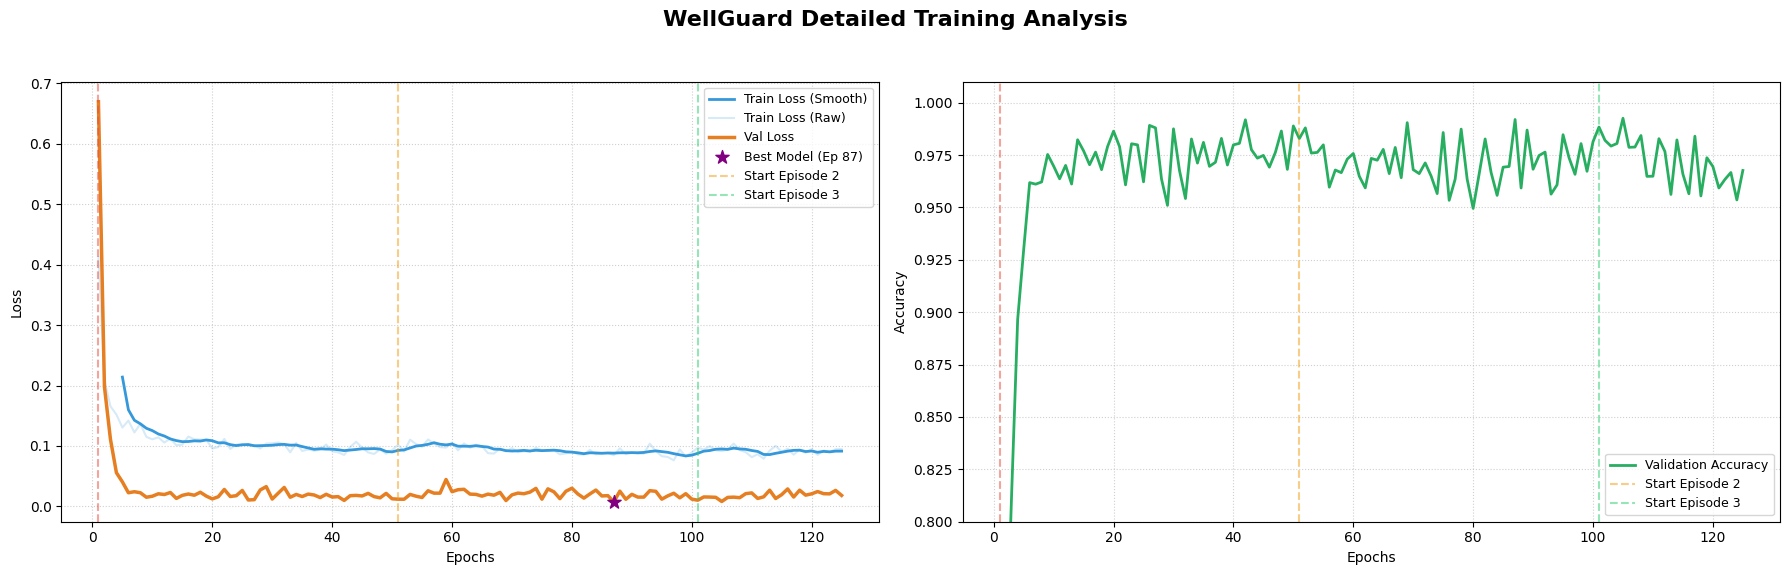

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_detailed_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('WellGuard Detailed Training Analysis', fontsize=16, fontweight='bold')

    epochs = range(1, len(history['val_loss']) + 1)
    bounds = history['episode_boundaries']
    ep_colors = ['#e74c3c', '#f39c12', '#2ecc71']

    # --- Subplot 1: Loss Analysis ---
    ax1 = axes[0]
    # Smooth train loss using a simple moving average
    train_loss = np.array(history['train_loss'])
    if len(train_loss) > 5:
        smooth_loss = np.convolve(train_loss, np.ones(5)/5, mode='valid')
        ax1.plot(range(5, len(train_loss) + 1), smooth_loss, color='#3498db', linewidth=2, label='Train Loss (Smooth)')
        ax1.plot(epochs, train_loss, color='#3498db', alpha=0.2, label='Train Loss (Raw)')
    else:
        ax1.plot(epochs, train_loss, color='#3498db', label='Train Loss')

    ax1.plot(epochs, history['val_loss'], color='#e67e22', linewidth=2.5, label='Val Loss')

    # Mark Best Model
    best_ep = np.argmin(history['val_loss'])
    ax1.scatter(best_ep + 1, history['val_loss'][best_ep], color='purple', s=100, zorder=5, marker='*', label=f'Best Model (Ep {best_ep+1})')

    # --- Subplot 2: Accuracy Analysis ---
    ax2 = axes[1]
    ax2.plot(epochs, history['val_acc'], color='#27ae60', linewidth=2, label='Validation Accuracy')
    ax2.set_ylim(0.8, 1.01) # Zoom in to see details in high accuracy range

    # Add Episode Boundaries & Styling to both
    for ax in axes:
        for i, b in enumerate(bounds):
            ax.axvline(x=b+1, color=ep_colors[i % len(ep_colors)], linestyle='--', alpha=0.5, label=f'Start Episode {i+1}' if b > 0 else '')
        ax.set_xlabel('Epochs')
        ax.grid(True, which='both', linestyle=':', alpha=0.6)
        ax.legend(fontsize=9, loc='best')

    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Accuracy')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Simpan ke dictionary untuk di-export ke Drive nanti
    SAVED_FIGS['hist_detailed'] = fig
    plt.show()

plot_detailed_history(history)

## 🧪 Cell 16 — Evaluasi Komprehensif pada Test Set

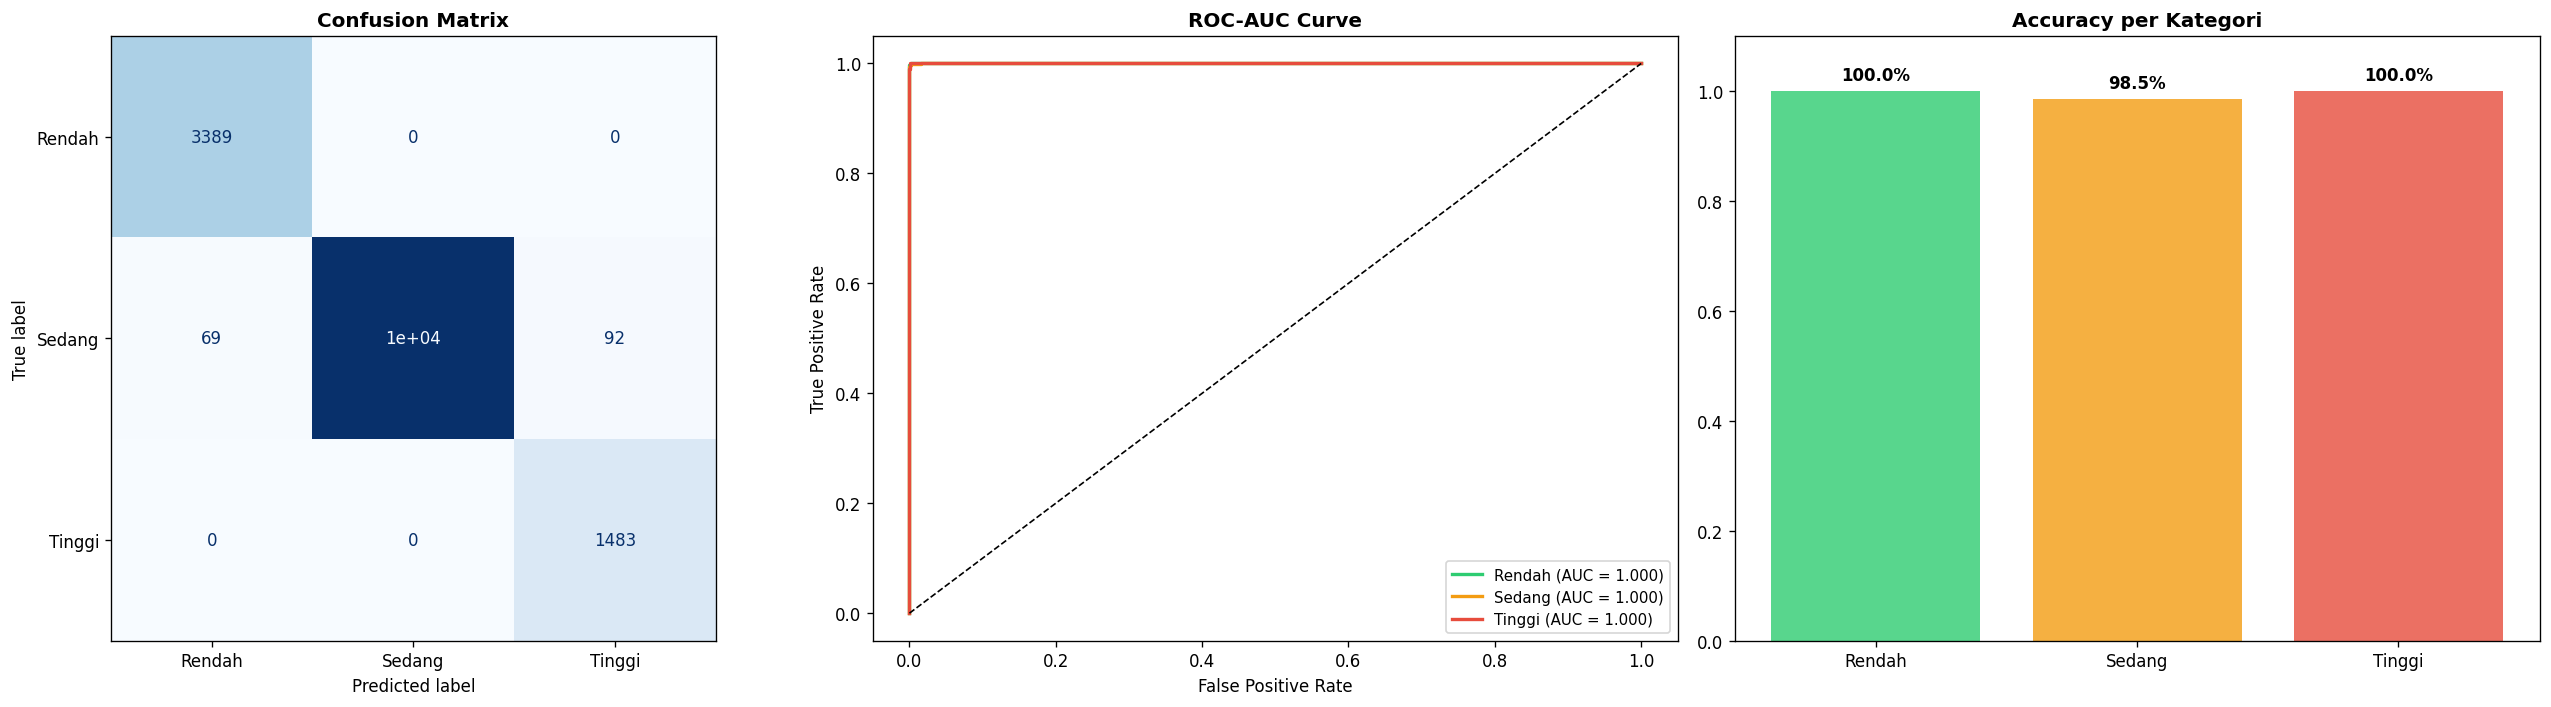

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Definisikan nama kelas
CLASS_NAMES = ['Rendah', 'Sedang', 'Tinggi']

# 1. Hitung Prediksi dan Probabilitas
model.eval()
with torch.no_grad():
    logits_test = model(torch.from_numpy(X_test).to(DEVICE))
    probs_test  = F.softmax(logits_test, dim=1).cpu().numpy()
    preds_test  = logits_test.argmax(1).cpu().numpy()

fig_eval, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=120)

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_test, preds_test)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# --- B. ROC-AUC Curve (One-vs-Rest) ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colors[i], lw=2, label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC-AUC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

# --- C. Per-Class Accuracy ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
axes[2].bar(CLASS_NAMES, per_class_acc, color=colors, alpha=0.8)
axes[2].set_title('Accuracy per Kategori', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(per_class_acc):
    axes[2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
SAVED_FIGS['eval_complete'] = fig_eval
plt.show()

## 🔍 Cell 17 — SHAP Feature Importance
Mengidentifikasi kontribusi tiap fitur terhadap prediksi risiko fatigue **Tinggi** —  
fitur paling berpengaruh untuk tindakan preventif K3.

⏳ Menghitung SHAP (ini mungkin memakan waktu sejenak)...


  0%|          | 0/60 [00:00<?, ?it/s]

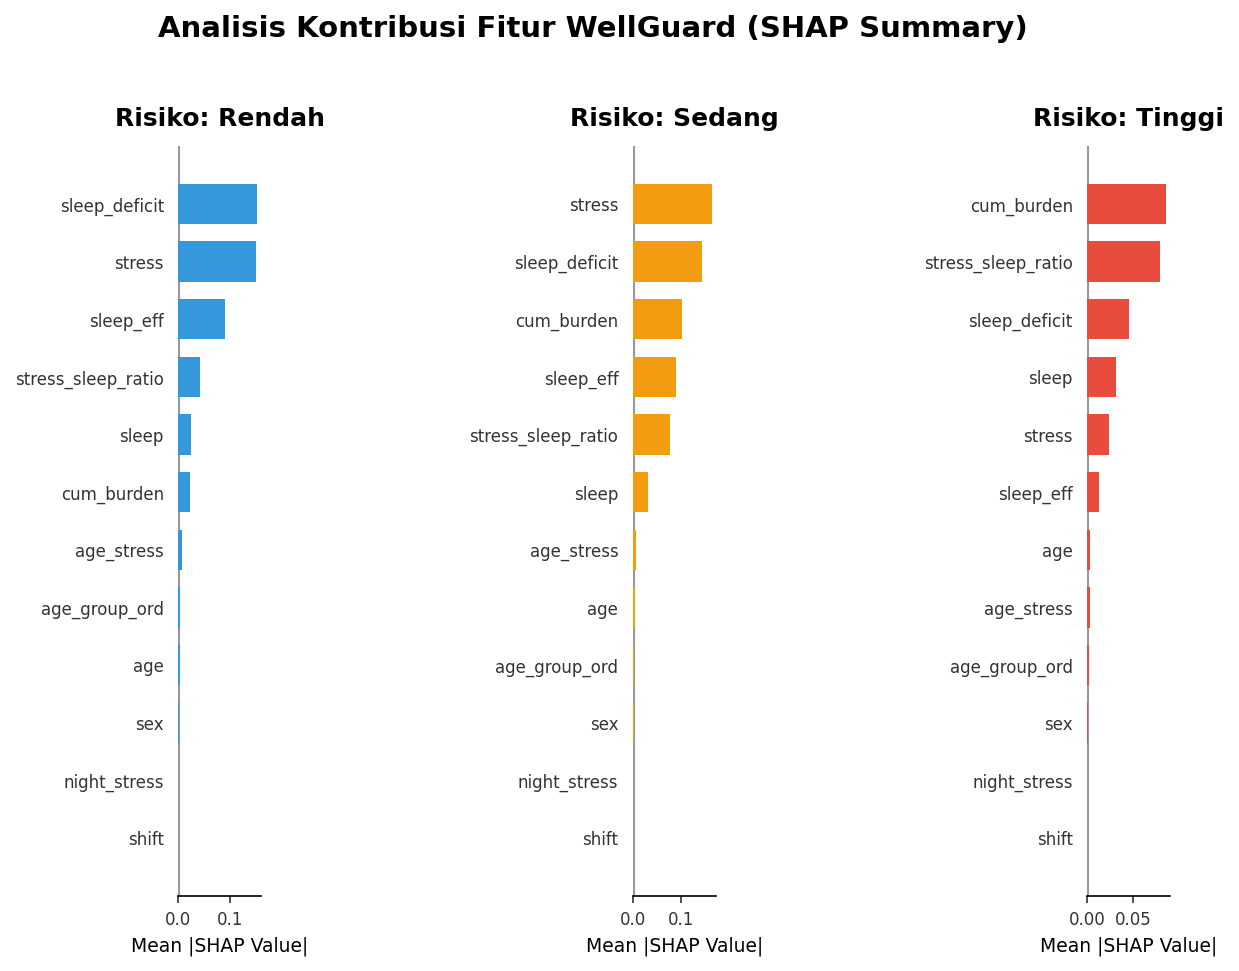

In [21]:
import shap
import matplotlib.pyplot as plt
import torch
import numpy as np

print('⏳ Menghitung SHAP (ini mungkin memakan waktu sejenak)...')

def shap_predict(data_numpy):
    X_torch = torch.from_numpy(data_numpy).float().to(DEVICE)
    model.eval()
    with torch.no_grad():
        return model.predict_proba(X_torch).cpu().numpy()

bg_idx = np.random.choice(len(X_train), 100, replace=False)
explainer = shap.KernelExplainer(shap_predict, X_train[bg_idx])

samp_idx = np.random.choice(len(X_test), 60, replace=False)
X_samp = X_test[samp_idx]
shap_results = explainer.shap_values(X_samp)

shap_values_list = shap_results if isinstance(shap_results, list) else [shap_results[:,:,i] for i in range(shap_results.shape[2])]

# Layout yang lebih proporsional dengan judul yang dikecilkan
fig_shap, axes = plt.subplots(1, 3, figsize=(22, 8), dpi=150)
fig_shap.suptitle('Analisis Kontribusi Fitur WellGuard (SHAP Summary)', fontsize=14, fontweight='bold', y=1.02)

colors = ['#3498db', '#f39c12', '#e74c3c']

for i, cls_name in enumerate(CLASS_NAMES):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values_list[i],
        X_samp,
        feature_names=CFG['feature_cols'],
        plot_type='bar',
        show=False,
        color=colors[i],
        max_display=12
    )
    # Penyesuaian font agar tidak 'behamburan'
    axes[i].set_title(f'Risiko: {cls_name}', fontsize=12, pad=10, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP Value|', fontsize=9)
    axes[i].tick_params(axis='both', which='major', labelsize=8)

# w_pad ditingkatkan menjadi 10.0 agar ada ruang kosong yang jelas antar kolom
plt.tight_layout(w_pad=10.0)

# Update dictionary untuk penyimpanan ke Drive
SAVED_FIGS['shap'] = fig_shap
plt.show()

## 💾 Cell 18 — Simpan Model & Metadata

In [22]:
# Metadata model untuk reproduksibilitas dan inferensi
meta = {
    'model_version'   : '1.0',
    'project'         : 'Nuraga CC26-PRU428',
    'feature_cols'    : CFG['feature_cols'],
    'n_classes'       : CFG['n_classes'],
    'class_labels'    : {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'},
    'plr_emb_dim'     : CFG['plr_emb_dim'],
    'plr_sigma'       : CFG['plr_sigma'],
    'hidden_dims'     : CFG['hidden_dims'],
    'dropout_rates'   : list(CFG['dropout_rates']),
    'activation'      : 'SELU',
    'scaler'          : 'RobustScaler',
    'mixup_alpha'     : CFG['mixup_alpha'],
    'ema_decay'       : CFG['ema_decay'],
    'imwa_episodes'   : CFG['imwa_episodes'],
    'loss_fn'         : 'FocalLoss + LabelSmoothing',
    'val_loss_best'   : float(min(history['val_loss'])),
    'val_acc_best'    : float(max(history['val_acc'])),
    'n_params'        : sum(p.numel() for p in model.parameters() if p.requires_grad),
    'data_source'     : 'wellguard.csv (output EDA notebook)',
}

with open(CFG['meta_path'], 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('✅ Semua artefak tersimpan:')
for k, v in [
    ('Model weights', CFG['best_model_path']),
    ('RobustScaler' , CFG['scaler_path']),
    ('Metadata JSON', CFG['meta_path']),
]:
    print(f'   {k:14s} → {v}')

✅ Semua artefak tersimpan:
   Model weights  → /content/drive/MyDrive/WellGuard/model_output/wellguard_model.pt
   RobustScaler   → /content/drive/MyDrive/WellGuard/model_output/robust_scaler.pkl
   Metadata JSON  → /content/drive/MyDrive/WellGuard/model_output/model_meta.json


In [23]:
import json, os
DRIVE_SAVE_PATH = CFG['output_dir']

# 1. Simpan Metadata
with open(os.path.join(DRIVE_SAVE_PATH, 'meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

# 2. Simpan Plot dari Dictionary
for name, fig in SAVED_FIGS.items():
    save_path = os.path.join(DRIVE_SAVE_PATH, f'{name}.png')
    fig.savefig(save_path, dpi=120, bbox_inches='tight')
    print(f'✅ Berhasil menyimpan: {save_path}')

✅ Berhasil menyimpan: /content/drive/MyDrive/WellGuard/model_output/dist.png
✅ Berhasil menyimpan: /content/drive/MyDrive/WellGuard/model_output/hist_detailed.png
✅ Berhasil menyimpan: /content/drive/MyDrive/WellGuard/model_output/eval_complete.png
✅ Berhasil menyimpan: /content/drive/MyDrive/WellGuard/model_output/shap.png


## 📂 Final Sync & Drive Verification
Cell ini memastikan semua artefak (model, scaler, metadata, dan plot) telah tersinkronisasi dengan benar di Google Drive dan mencetak ringkasan final.

In [24]:
import os
from datetime import datetime

# Pastikan direktori ada
output_path = CFG['output_dir']

# Buat file ringkasan performa sederhana (txt)
summary_file = os.path.join(output_path, 'performance_summary.txt')
with open(summary_file, 'w') as f:
    f.write(f"WellGuard Model Training Summary\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"="*40 + "\n")
    f.write(f"Best Val Loss: {min(history['val_loss']):.4f}\n")
    f.write(f"Best Val Acc: {max(history['val_acc']):.4f}\n")
    f.write(f"Total Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")
    f.write(f"="*40 + "\n")

print(f"✅ Sinkronisasi Selesai di: {output_path}")
print("\nIsi Folder Output:")
!ls -lh "$output_path"

✅ Sinkronisasi Selesai di: /content/drive/MyDrive/WellGuard/model_output

Isi Folder Output:
total 41M
-rw------- 1 root root 106K May 25 08:55 dist.png
-rw------- 1 root root  82K May 25 08:55 eval_complete.png
-rw------- 1 root root 183K May 25 08:55 hist_detailed.png
-rw------- 1 root root  869 May 25 08:55 meta.json
-rw------- 1 root root  869 May 25 08:55 model_meta.json
-rw------- 1 root root  217 May 25 08:55 performance_summary.txt
-rw------- 1 root root  679 May 25 08:38 robust_scaler.pkl
-rw------- 1 root root  50K May 25 08:55 shap.png
-rw------- 1 root root 5.7M May 25 08:49 wellguard_model.pt
-rw------- 1 root root 5.7M May 25 08:41 wellguard_model.pt.tmp_ep1_p0
-rw------- 1 root root 5.7M May 25 08:43 wellguard_model.pt.tmp_ep1_p1
-rw------- 1 root root 5.7M May 25 08:46 wellguard_model.pt.tmp_ep2_p0
-rw------- 1 root root 5.7M May 25 08:47 wellguard_model.pt.tmp_ep2_p1
-rw------- 1 root root 5.7M May 25 08:49 wellguard_model.pt.tmp_ep3_p0
-rw------- 1 root root 5.7M May 

## 🔮 Cell 19 — Inferensi Single Sample (Streamlit-compatible)
Fungsi `predict_fatigue_risk()` menerima data mentah satu pekerja dan mengembalikan prediksi beserta probabilitas per kelas.

In [25]:
def predict_fatigue_risk(
    worker_data : dict,
    model       : nn.Module,
    scaler,
    cfg         : dict,
) -> dict:
    """
    Prediksi risiko fatigue untuk satu pekerja.
    Kompatibel dengan antarmuka Streamlit Nuraga.

    Parameter:
        worker_data : dict dengan kunci minimal:
                      {age, sex, sleep, stress}
                      shift dan age_group opsional (default: shift=1)

    Return:
        dict {
            'predicted_class'  : int   (0=Rendah, 1=Sedang, 2=Tinggi)
            'predicted_label'  : str
            'probabilities'    : dict  {kelas: float}
            'confidence'       : float (probabilitas kelas prediksi)
            'risk_flag'        : bool  (True jika prediksi = Tinggi)
        }
    """
    CLASS_NAMES = ['Rendah', 'Sedang', 'Tinggi']

    df_single = engineer_features(pd.DataFrame([worker_data]))

    # Isi kolom yang mungkin tidak ada
    for col in cfg['feature_cols']:
        if col not in df_single.columns:
            df_single[col] = 0.0

    X_raw    = df_single[cfg['feature_cols']].values.astype(np.float32)
    X_scaled = scaler.transform(X_raw)

    model.eval()
    x_t = torch.from_numpy(X_scaled).float().to(DEVICE)
    with torch.no_grad():
        prob = F.softmax(model(x_t), dim=1).cpu().numpy()[0]

    cls = int(np.argmax(prob))
    return {
        'predicted_class' : cls,
        'predicted_label' : CLASS_NAMES[cls],
        'probabilities'   : dict(zip(CLASS_NAMES, [round(float(p), 4) for p in prob])),
        'confidence'      : round(float(prob[cls]), 4),
        'risk_flag'       : cls == 2,
    }


# ── Contoh inferensi ──────────────────────────────────────────────────────────
contoh_pekerja = {
    'age'   : 42,
    'sex'   : 1,       # 1 = Male
    'sleep' : 4.5,     # jam tidur
    'stress': 8.0,     # skor stres 1–10
    'shift' : 2,       # 2 = shift malam
}

hasil = predict_fatigue_risk(contoh_pekerja, model, scaler, CFG)

print('\n🔮 Contoh Inferensi:')
print(f'   Input    : {contoh_pekerja}')
print(f'   Prediksi : {hasil["predicted_label"]}  (confidence: {hasil["confidence"]:.2%})')
print(f'   Prob     : {hasil["probabilities"]}')
print(f'   Risk Flag: {"⚠️ RISIKO TINGGI" if hasil["risk_flag"] else "✅ Aman"}')


🔮 Contoh Inferensi:
   Input    : {'age': 42, 'sex': 1, 'sleep': 4.5, 'stress': 8.0, 'shift': 2}
   Prediksi : Tinggi  (confidence: 97.83%)
   Prob     : {'Rendah': 0.0074, 'Sedang': 0.0143, 'Tinggi': 0.9783}
   Risk Flag: ⚠️ RISIKO TINGGI


##⌨️ Test Manual Interaktif
Jalankan cell di bawah ini untuk mencoba model dengan data kustom secara berulang.

In [26]:
print("=== WellGuard Interactive Test ===")
print("Ketik 'Q' pada input manapun untuk berhenti.\n")

while True:
    try:
        age_in = input("Masukkan Usia (contoh: 30): ")
        if age_in.upper() == 'Q': break

        sex_in = input("Masukkan Jenis Kelamin (0: Pria, 1: Wanita): ")
        if sex_in.upper() == 'Q': break

        sleep_in = input("Masukkan Jam Tidur (contoh: 6.5): ")
        if sleep_in.upper() == 'Q': break

        stress_in = input("Masukkan Skor Stres (1-10): ")
        if stress_in.upper() == 'Q': break

        shift_in = input("Masukkan Shift (1: Siang, 2: Malam): ")
        if shift_in.upper() == 'Q': break

        # Konversi data
        data_input = {
            'age': float(age_in),
            'sex': float(sex_in),
            'sleep': float(sleep_in),
            'stress': float(stress_in),
            'shift': int(shift_in)
        }

        # Jalankan Prediksi
        res = predict_fatigue_risk(data_input, model, scaler, CFG)

        # Tampilkan Hasil
        print("\n" + "="*40)
        status_icon = "⚠️" if res['risk_flag'] else "✅"
        print(f"{status_icon} HASIL PREDIKSI: {res['predicted_label'].upper()}")
        print(f"   Confidence: {res['confidence']:.2%}")
        print(f"   Detail Probabilitas: {res['probabilities']}")
        print("="*40 + "\n")

    except ValueError:
        print("\n❌ Error: Harap masukkan angka yang valid atau 'Q' untuk keluar.\n")
    except Exception as e:
        print(f"\n❌ Terjadi kesalahan: {e}\n")

print("\n✅ Sesi interaktif berakhir.")

=== WellGuard Interactive Test ===
Ketik 'Q' pada input manapun untuk berhenti.

Masukkan Usia (contoh: 30): 23
Masukkan Jenis Kelamin (0: Pria, 1: Wanita): 1
Masukkan Jam Tidur (contoh: 6.5): 4.1
Masukkan Skor Stres (1-10): 9
Masukkan Shift (1: Siang, 2: Malam): 1

⚠️ HASIL PREDIKSI: TINGGI
   Confidence: 96.12%
   Detail Probabilitas: {'Rendah': 0.0136, 'Sedang': 0.0253, 'Tinggi': 0.9612}

Masukkan Usia (contoh: 30): q

✅ Sesi interaktif berakhir.


---
## 📋 Ringkasan Pipeline

| Tahap | Cell | Keterangan |
|---|---|---|
| Instalasi | 0 | Shap, NumPy guard |
| Import | 1 | Semua library |
| Konfigurasi | 2 | CFG dict + mount Drive |
| Data | 3 | Load wellguard.csv + 6 fitur turunan |
| EDA cepat | 4 | Distribusi 12 fitur per kelas |
| Dataset | 5 | FatigueDataset + WeightedSampler |
| PLR | 6 | Numerical embedding 12→192 dim |
| Model | 7 | WellGuardMLP (ResBlocks + SELU) |
| Loss | 8 | Focal Loss + Label Smoothing |
| Mixup | 9 | Augmentasi untuk imbalanced data |
| EMA | 10 | Exponential Moving Average |
| Loop | 11 | train_one_epoch + evaluate |
| IMWA | 12 | 3 episode × 2 paralel + averaging |
| Scaling | 13 | RobustScaler + 70/15/15 split |
| Training | 14 | **Jalankan pipeline utama** |
| Kurva | 15 | Loss & accuracy dengan batas episode |
| Evaluasi | 16 | Classification report + CM + per-class acc |
| SHAP | 17 | Feature importance untuk semua kelas |
| Simpan | 18 | Model, scaler, metadata JSON |
| Inferensi | 19 | predict_fatigue_risk() untuk Streamlit |

**Artefak output yang dihasilkan:**
- `wellguard_model.pt` — bobot model terbaik
- `robust_scaler.pkl` — scaler untuk inferensi
- `model_meta.json` — metadata lengkap
- `feature_distributions.png` — distribusi fitur
- `training_history.png` — kurva training
- `evaluation_results.png` — confusion matrix + akurasi
- `shap_importance.png` — SHAP per kelas